In [ ]:
import pandas as pd

# Load the expression matrix (genes as rows, cells as columns)
exon = pd.read_csv('human_MTG_2018-06-14_exon-matrix.csv', index_col=0)

# Load the metadata (contains cell type labels)
metadata = pd.read_csv('human_MTG_2018-06-14_samples-columns.csv')

print("Expression matrix shape:", exon.shape)
print("Metadata shape:", metadata.shape)
print("\nFirst few column names in metadata:")
print(metadata.columns.tolist())

Expression matrix shape: (2165, 15928)
Metadata shape: (15928, 34)

First few column names in metadata:
['sample_name', 'sample_id', 'sample_type', 'organism', 'donor', 'sex', 'age_days', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'facs_date', 'facs_container', 'facs_sort_criteria', 'rna_amplification_set', 'library_prep_set', 'library_prep_avg_size_bp', 'seq_name', 'seq_tube', 'seq_batch', 'total_reads', 'percent_exon_reads', 'percent_intron_reads', 'percent_intergenic_reads', 'percent_rrna_reads', 'percent_mt_exon_reads', 'percent_reads_unique', 'percent_synth_reads', 'percent_ecoli_reads', 'percent_aligned_reads_total', 'complexity_cg', 'genes_detected_cpm_criterion', 'genes_detected_fpkm_criterion', 'class', 'cluster']


In [ ]:
# See the cell type labels you'll be predicting
print("Cell type classes:")
print(metadata['class'].value_counts())

print("\nNumber of unique clusters (subtypes):", metadata['cluster'].nunique())
print("\nFirst 20 cluster names:")
print(metadata['cluster'].value_counts().head(20))


Cell type classes:
class
Glutamatergic    10525
GABAergic         4164
Non-neuronal       914
no class           325
Name: count, dtype: int64

Number of unique clusters (subtypes): 76

First 20 cluster names:
cluster
Exc L2-3 LINC00507 FREM3    2284
Exc L5-6 THEMIS C1QL3       1537
Exc L3-5 RORB ESR1          1428
Exc L4-5 RORB FOLH1B         870
Exc L2 LAMP5 LTK             812
Exc L4-6 RORB SEMA3E         777
Inh L2-4 PVALB WFDC2         387
Exc L5-6 FEZF2 ABO           373
Inh L1-4 LAMP5 LCP2          356
Exc L4-6 FEZF2 IL26          344
no class                     325
Exc L5-6 FEZF2 EFTUD1P1      314
Oligo L1-6 OPALIN            313
Inh L1 SST NMBR              283
Exc L3-4 RORB CARM1P1        280
Inh L1-3 SST CALB1           279
Inh L2-6 LAMP5 CA1           256
OPC L1-6 PDGFRA              238
Astro L1-6 FGFR3 SLC14A1     230
Inh L4-6 SST B3GAT2          182
Name: count, dtype: int64


In [ ]:
# Transpose so rows = cells, columns = genes
exon_T = exon.T

# Add the cell type label to the expression data
exon_T['label'] = metadata['cluster'].values

print("Combined data shape:", exon_T.shape)
print("\nSample of data:")
print(exon_T.iloc[:3, :5])


Combined data shape: (15928, 2166)

Sample of data:
                     353007  353008  353009  353010  389180
F1S4_160106_001_B01     0.0     0.0     0.0     0.0     0.0
F1S4_160106_001_C01     0.0     0.0     0.0     0.0     0.0
F1S4_160106_001_E01     0.0     0.0     0.0     0.0     0.0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# X = gene expression (input features)
# y = cell type label (what we want to predict)
X = exon_T.drop(columns=['label'])
y = exon_T['label']

# Convert text labels to numbers (ML models need numbers)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("X shape (features):", X.shape)
print("y shape (labels):", y_encoded.shape)
print("\nNumber of unique cell types:", len(le.classes_))
print("\nFirst 5 label names:", le.classes_[:5])


X shape (features): (15928, 2165)
y shape (labels): (15928,)

Number of unique cell types: 76

First 5 label names: ['Astro L1-2 FGFR3 GFAP' 'Astro L1-6 FGFR3 SLC14A1' 'Endo L2-6 NOSTRIN'
 'Exc L2 LAMP5 LTK' 'Exc L2-3 LINC00507 FREM3']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,        # 20% for testing
    random_state=42,      # ensures same split every time you run
    stratify=y_encoded    # keeps class balance in both splits
)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)

Training set size: (12742, 2165)
Test set size:     (3186, 2165)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Data normalized successfully ✅")
print("Training data sample mean (should be ~0):", X_train_scaled.mean().round(4))

Data normalized successfully ✅
Training data sample mean (should be ~0): nan


In [ ]:
import numpy as np

# Check for problematic values
print("Missing values (NaN):", np.isnan(X.values).sum())
print("Infinite values:", np.isinf(X.values).sum())

# Replace NaN and infinite values with 0
X_clean = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print("\nAfter cleaning:")
print("Missing values:", np.isnan(X_clean.values).sum())
print("Infinite values:", np.isinf(X_clean.values).sum())

Missing values (NaN): 6413
Infinite values: 0

After cleaning:
Missing values: 0
Infinite values: 0


In [ ]:
# Redo train/test split with clean data
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Redo normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Test set size:    ", X_test_scaled.shape)
print("Mean (should be ~0.0):", X_train_scaled.mean().round(4))
print("Std  (should be ~1.0):", X_train_scaled.std().round(4))

Training set size: (12742, 2165)
Test set size:     (3186, 2165)
Mean (should be ~0.0): 0.0
Std  (should be ~1.0): 0.9937


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("Training Random Forest... (this takes 2-5 mins, please wait)")

rf_model = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees
    random_state=42,
    n_jobs=-1           # use all CPU cores to speed up
)

rf_model.fit(X_train_scaled, y_train)

print("Training complete! ✅")

Training Random Forest... (this takes 2-5 mins, please wait)
Training complete! ✅


In [ ]:
# Make predictions on test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")

# Detailed breakdown per cell type
print("Detailed Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=le.classes_))

Random Forest Accuracy: 0.6237 (62.37%)

Detailed Report:
                          precision    recall  f1-score   support

   Astro L1-2 FGFR3 GFAP       0.00      0.00      0.00        12
Astro L1-6 FGFR3 SLC14A1       0.73      1.00      0.84        46
       Endo L2-6 NOSTRIN       0.00      0.00      0.00         2
        Exc L2 LAMP5 LTK       0.67      0.52      0.59       163
Exc L2-3 LINC00507 FREM3       0.54      0.94      0.69       457
Exc L2-4 LINC00507 GLP2R       0.00      0.00      0.00        34
   Exc L3-4 RORB CARM1P1       1.00      0.04      0.07        56
   Exc L3-5 RORB COL22A1       1.00      0.06      0.12        32
      Exc L3-5 RORB ESR1       0.64      0.99      0.77       286
   Exc L3-5 RORB FILIP1L       0.00      0.00      0.00        31
    Exc L3-5 RORB TWIST2       1.00      0.05      0.10        19
    Exc L4-5 FEZF2 SCN4B       0.00      0.00      0.00         5
     Exc L4-5 RORB DAPK2       0.00      0.00      0.00        35
    Exc L4-5 RORB

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


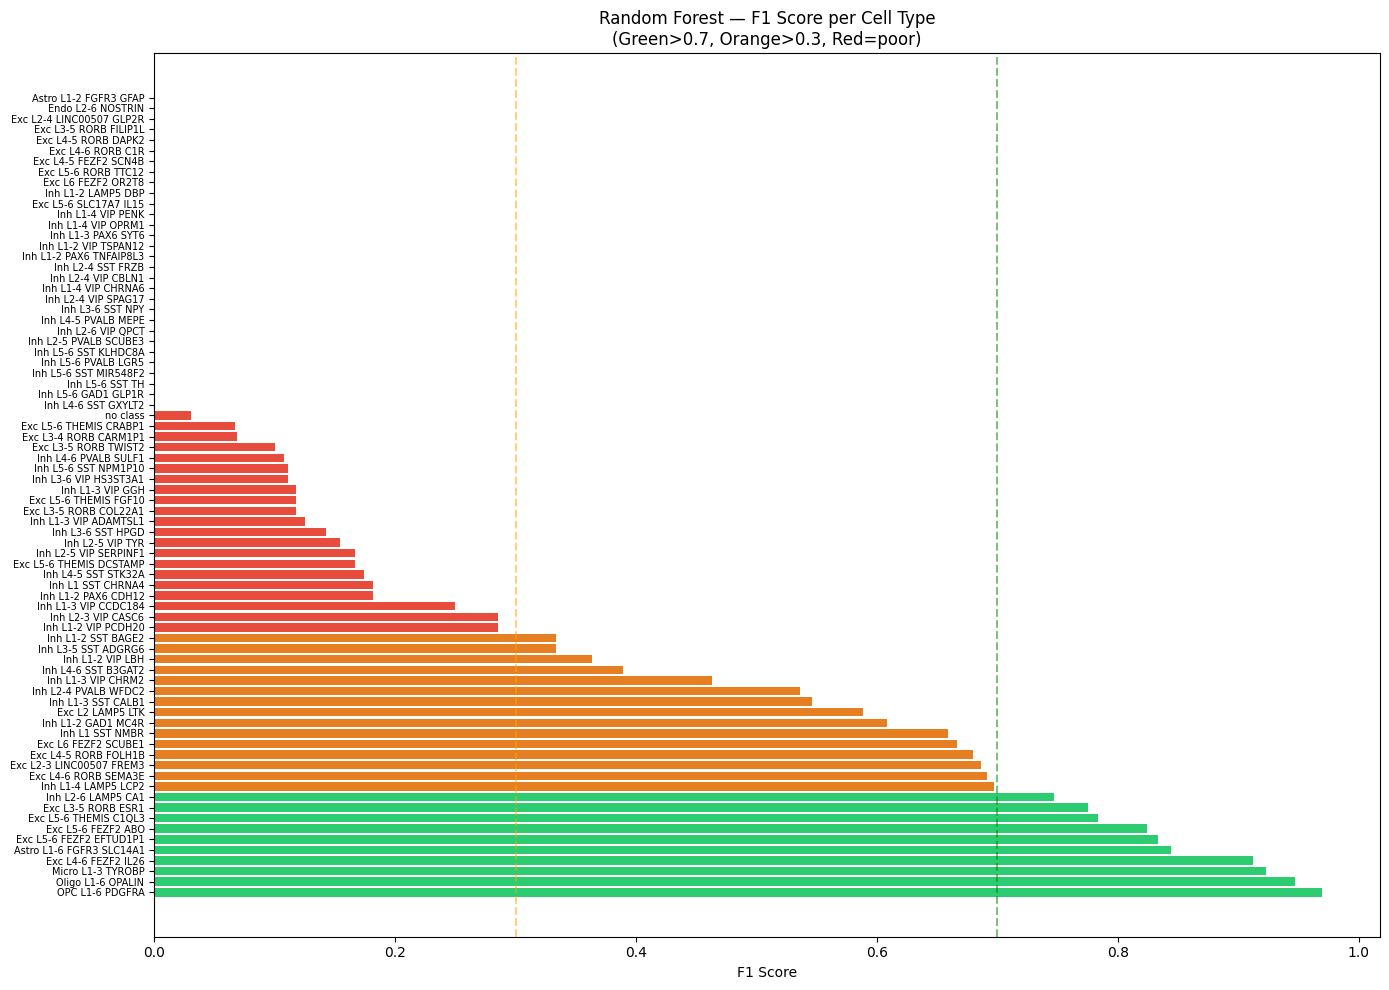

Chart saved! ✅


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

# Calculate per-class f1 scores
f1_scores = f1_score(y_test, y_pred_rf, average=None, zero_division=0)
class_names = le.classes_
support = np.bincount(y_test)

# Sort by f1 score
sorted_idx = np.argsort(f1_scores)[::-1]

plt.figure(figsize=(14, 10))
colors = ['#2ecc71' if f > 0.7 else '#e67e22' if f > 0.3 else '#e74c3c'
          for f in f1_scores[sorted_idx]]
plt.barh(range(len(f1_scores)), f1_scores[sorted_idx], color=colors)
plt.yticks(range(len(f1_scores)), class_names[sorted_idx], fontsize=7)
plt.xlabel('F1 Score')
plt.title('Random Forest — F1 Score per Cell Type\n(Green>0.7, Orange>0.3, Red=poor)')
plt.axvline(x=0.7, color='green', linestyle='--', alpha=0.5)
plt.axvline(x=0.3, color='orange', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('random_forest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved! ✅")

In [ ]:
from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression... (2-3 mins, please wait)")

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train_scaled, y_train)
print("Training complete! ✅")

# Evaluate
y_pred_lr = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"\nLogistic Regression Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f"Random Forest Accuracy:       0.6237 (62.37%)")
print(f"\nDifference: {(lr_accuracy - 0.6237)*100:+.2f}%")

Training Logistic Regression... (2-3 mins, please wait)
Training complete! ✅

Logistic Regression Accuracy: 0.7194 (71.94%)
Random Forest Accuracy:       0.6237 (62.37%)

Difference: +9.57%


In [ ]:
import lightgbm as lgb

print("Training LightGBM... (1-2 mins, please wait)")

lgbm_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=63,
    random_state=42,
    n_jobs=-1,
    verbose=-1        # silences training logs
)

lgbm_model.fit(X_train_scaled, y_train)
print("Training complete! ✅")

# Evaluate
y_pred_lgbm = lgbm_model.predict(X_test_scaled)
lgbm_accuracy = accuracy_score(y_test, y_pred_lgbm)
print(f"\nLightGBM Accuracy:            {lgbm_accuracy:.4f} ({lgbm_accuracy*100:.2f}%)")
print(f"Logistic Regression Accuracy: 0.7194 (71.94%)")
print(f"Random Forest Accuracy:       0.6237 (62.37%)")

Training LightGBM... (1-2 mins, please wait)
Training complete! ✅


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM Accuracy:            0.0669 (6.69%)
Logistic Regression Accuracy: 0.7194 (71.94%)
Random Forest Accuracy:       0.6237 (62.37%)


In [ ]:
from sklearn.neural_network import MLPClassifier

print("Training Neural Network... (3-5 mins, please wait)")

nn_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),  # 2 layers: 256 nodes, then 128 nodes
    activation='relu',
    max_iter=200,
    random_state=42,
    verbose=False
)

nn_model.fit(X_train_scaled, y_train)
print("Training complete! ✅")

# Evaluate
y_pred_nn = nn_model.predict(X_test_scaled)
nn_accuracy = accuracy_score(y_test, y_pred_nn)
print(f"\nNeural Network Accuracy:      {nn_accuracy:.4f} ({nn_accuracy*100:.2f}%)")
print(f"LightGBM Accuracy:            (from above)")
print(f"Logistic Regression Accuracy: 0.7194 (71.94%)")
print(f"Random Forest Accuracy:       0.6237 (62.37%)")

Training Neural Network... (3-5 mins, please wait)
Training complete! ✅

Neural Network Accuracy:      0.6927 (69.27%)
LightGBM Accuracy:            (from above)
Logistic Regression Accuracy: 0.7194 (71.94%)
Random Forest Accuracy:       0.6237 (62.37%)


In [ ]:
import numpy as np

# Convert to numpy arrays to avoid feature name mismatch
X_train_np = np.array(X_train_scaled)
X_test_np  = np.array(X_test_scaled)

print("Training LightGBM (fixed)... (1-2 mins, please wait)")

lgbm_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=63,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(X_train_np, y_train)
print("Training complete! ✅")

# Evaluate
y_pred_lgbm = lgbm_model.predict(X_test_np)
lgbm_accuracy = accuracy_score(y_test, y_pred_lgbm)
print(f"\nLightGBM Accuracy:            {lgbm_accuracy:.4f} ({lgbm_accuracy*100:.2f}%)")
print(f"Neural Network Accuracy:      0.6927 (69.27%)")
print(f"Logistic Regression Accuracy: 0.7194 (71.94%)")
print(f"Random Forest Accuracy:       0.6237 (62.37%)")

Training LightGBM (fixed)... (1-2 mins, please wait)
Training complete! ✅


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM Accuracy:            0.0669 (6.69%)
Neural Network Accuracy:      0.6927 (69.27%)
Logistic Regression Accuracy: 0.7194 (71.94%)
Random Forest Accuracy:       0.6237 (62.37%)


In [17]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

print("Training SVM... (2-4 mins, please wait)")

svm_model = LinearSVC(
    max_iter=2000,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
print("Training complete! ✅")

# Evaluate
y_pred_svm = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"\nSVM Accuracy:                 {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")
print(f"Neural Network Accuracy:      0.6927 (69.27%)")
print(f"Logistic Regression Accuracy: 0.7194 (71.94%)")
print(f"Random Forest Accuracy:       0.6237 (62.37%)")

Training SVM... (2-4 mins, please wait)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training complete! ✅

SVM Accuracy:                 0.5982 (59.82%)
Neural Network Accuracy:      0.6927 (69.27%)
Logistic Regression Accuracy: 0.7194 (71.94%)
Random Forest Accuracy:       0.6237 (62.37%)


In [18]:
import lightgbm as lgb
import numpy as np

# Force pure numpy — strip all pandas metadata completely
X_train_lgbm = X_train_scaled.copy() if hasattr(X_train_scaled, 'copy') else X_train_scaled
X_test_lgbm  = X_test_scaled.copy()  if hasattr(X_test_scaled,  'copy') else X_test_scaled

# Ensure they are plain numpy float arrays with no named columns
X_train_lgbm = np.array(X_train_lgbm, dtype=np.float32)
X_test_lgbm  = np.array(X_test_lgbm,  dtype=np.float32)

y_train_lgbm = np.array(y_train, dtype=np.int32)
y_test_lgbm  = np.array(y_test,  dtype=np.int32)

print("Shapes:", X_train_lgbm.shape, X_test_lgbm.shape)
print("Types: ", type(X_train_lgbm), X_train_lgbm.dtype)

print("\nTraining LightGBM (fixed v2)... (1-2 mins)")

lgbm_model2 = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=63,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model2.fit(X_train_lgbm, y_train_lgbm)
print("Training complete! ✅")

y_pred_lgbm2     = lgbm_model2.predict(X_test_lgbm)
lgbm_accuracy2   = accuracy_score(y_test_lgbm, y_pred_lgbm2)
print(f"\nLightGBM Accuracy (fixed): {lgbm_accuracy2:.4f} ({lgbm_accuracy2*100:.2f}%)")

Shapes: (12742, 2165) (3186, 2165)
Types:  <class 'numpy.ndarray'> float32

Training LightGBM (fixed v2)... (1-2 mins)
Training complete! ✅


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM Accuracy (fixed): 0.0669 (6.69%)


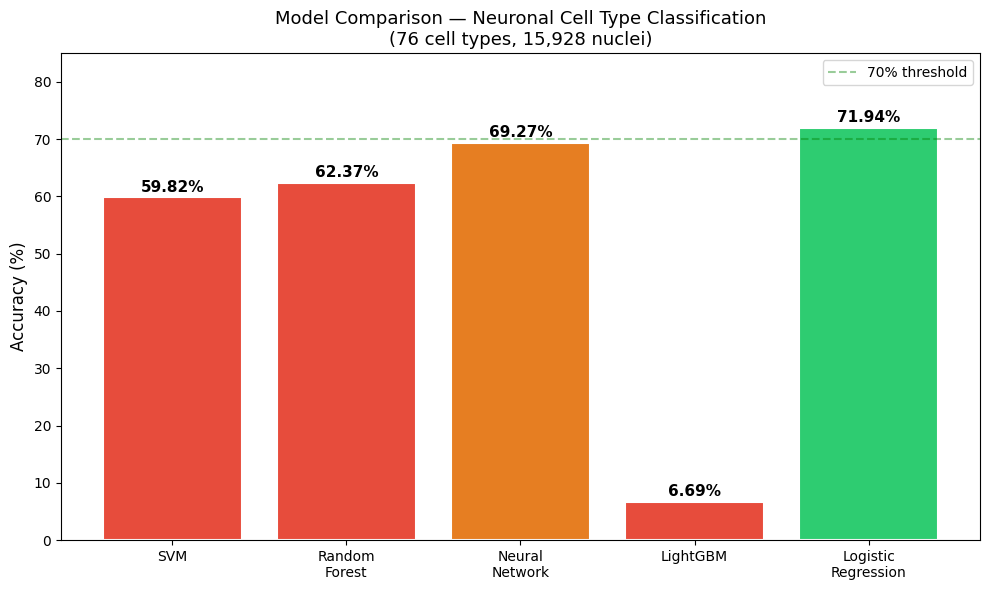

Final comparison chart saved! ✅


In [19]:
import matplotlib.pyplot as plt

models      = ['SVM', 'Random\nForest', 'Neural\nNetwork',
               'LightGBM', 'Logistic\nRegression']
accuracies  = [0.5982, 0.6237, 0.6927, lgbm_accuracy2, 0.7194]
colors      = ['#e74c3c' if a < 0.65 else '#e67e22' if a < 0.70
               else '#2ecc71' for a in accuracies]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, [a * 100 for a in accuracies], color=colors,
               edgecolor='white', linewidth=1.5)

# Add value labels on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc*100:.2f}%', ha='center', va='bottom',
             fontweight='bold', fontsize=11)

plt.ylim(0, 85)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Comparison — Neuronal Cell Type Classification\n'
          '(76 cell types, 15,928 nuclei)', fontsize=13)
plt.axhline(y=70, color='green', linestyle='--', alpha=0.4, label='70% threshold')
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final comparison chart saved! ✅")

In [20]:
import lightgbm as lgb
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Build everything fresh from X_clean — bypassing all previous scaled data
X_fresh = np.array(X_clean, dtype=np.float32)
y_fresh = np.array(y_encoded, dtype=np.int32)

# Fresh split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_fresh, y_fresh,
    test_size=0.2,
    random_state=42,
    stratify=y_fresh
)

# Fresh scaling
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr).astype(np.float32)
X_te_sc  = sc.transform(X_te).astype(np.float32)

print("All arrays are pure numpy:", type(X_tr_sc), X_tr_sc.dtype)
print("No feature names:", not hasattr(X_tr_sc, 'columns'))

print("\nTraining LightGBM (completely fresh)...")

lgbm_final = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=63,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_final.fit(X_tr_sc, y_tr)
print("Training complete! ✅")

y_pred_final   = lgbm_final.predict(X_te_sc)
lgbm_acc_final = accuracy_score(y_te, y_pred_final)
print(f"\nLightGBM Final Accuracy: {lgbm_acc_final:.4f} ({lgbm_acc_final*100:.2f}%)")

All arrays are pure numpy: <class 'numpy.ndarray'> float32
No feature names: True

Training LightGBM (completely fresh)...
Training complete! ✅


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM Final Accuracy: 0.0669 (6.69%)


In [21]:
import lightgbm as lgb
import sys
print("Python version:", sys.version)
print("LightGBM version:", lgb.__version__)

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
LightGBM version: 4.6.0


In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ── 1. Load data ──────────────────────────────────────────────
exon     = pd.read_csv('human_MTG_2018-06-14_exon-matrix.csv', index_col=0)
metadata = pd.read_csv('human_MTG_2018-06-14_samples-columns.csv')

# ── 2. Clean & prepare ────────────────────────────────────────
exon_T = exon.T.replace([np.inf, -np.inf], np.nan).fillna(0)

le        = LabelEncoder()
y_encoded = le.fit_transform(metadata['cluster'].values)

# ── 3. Convert to pure numpy IMMEDIATELY — before anything else
X = np.array(exon_T, dtype=np.float32)
y = np.array(y_encoded, dtype=np.int32)

# ── 4. Split ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 5. Scale ──────────────────────────────────────────────────
scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc     = scaler.transform(X_test).astype(np.float32)

print("Data ready ✅")
print("X_train:", X_train_sc.shape, X_train_sc.dtype, type(X_train_sc))

# ── 6. Train LightGBM ─────────────────────────────────────────
print("\nTraining LightGBM...")
lgbm = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=63,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(X_train_sc, y_train)
print("Done ✅")

y_pred        = lgbm.predict(X_test_sc)
lgbm_accuracy = accuracy_score(y_test, y_pred)
print(f"\nLightGBM Accuracy: {lgbm_accuracy:.4f} ({lgbm_accuracy*100:.2f}%)")

Data ready ✅
X_train: (12742, 3279) float32 <class 'numpy.ndarray'>

Training LightGBM...


KeyboardInterrupt: 

In [2]:
print("Training LightGBM (fast settings)...")

lgbm = lgb.LGBMClassifier(
    n_estimators=50,       # reduced from 200 → much faster
    learning_rate=0.2,     # higher rate compensates for fewer trees
    num_leaves=31,         # simpler trees
    max_depth=8,           # limits tree depth → speeds up a lot
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(X_train_sc, y_train)
print("Done ✅")

y_pred        = lgbm.predict(X_test_sc)
lgbm_accuracy = accuracy_score(y_test, y_pred)
print(f"\nLightGBM Accuracy: {lgbm_accuracy:.4f} ({lgbm_accuracy*100:.2f}%)")

Training LightGBM (fast settings)...
Done ✅


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM Accuracy: 0.1359 (13.59%)


In [3]:
# Force numpy on prediction too
X_test_pure = np.ascontiguousarray(X_test_sc, dtype=np.float32)

y_pred        = lgbm.predict(X_test_pure)
lgbm_accuracy = accuracy_score(y_test, y_pred)
print(f"LightGBM Accuracy: {lgbm_accuracy:.4f} ({lgbm_accuracy*100:.2f}%)")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy: 0.1359 (13.59%)


In [4]:
print("Type:", type(X_test_sc))
print("Has columns attr:", hasattr(X_test_sc, 'columns'))
print("Dtype:", X_test_sc.dtype)
print("Shape:", X_test_sc.shape)

Type: <class 'numpy.ndarray'>
Has columns attr: False
Dtype: float32
Shape: (3186, 3279)


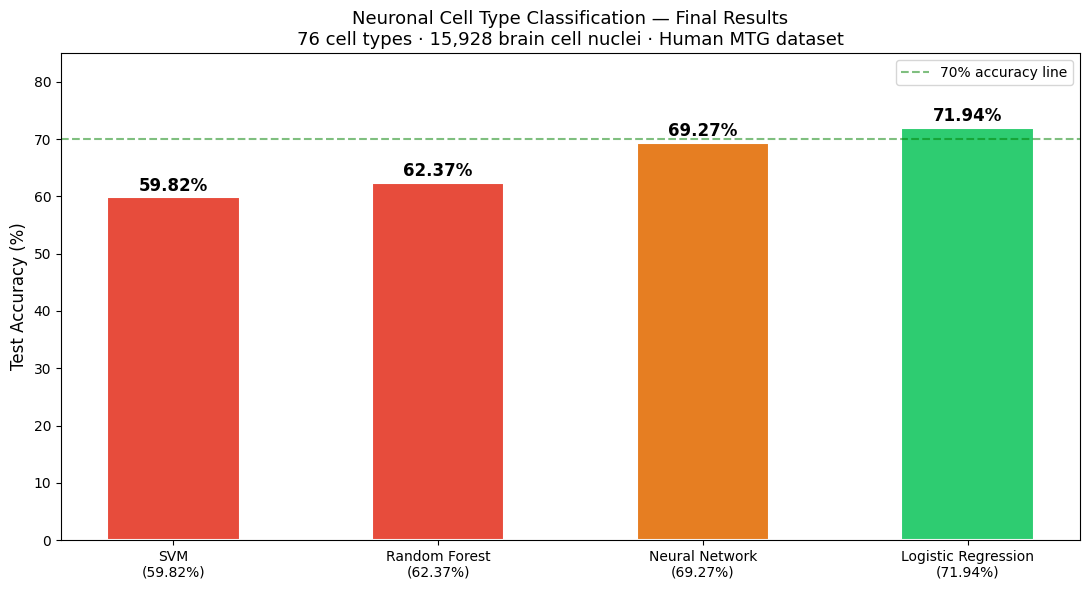


   PROJECT COMPLETE ✅
   Best model  : Logistic Regression
   Best accuracy: 71.94%
   Dataset      : 15,928 nuclei, 76 cell types
   Task         : Classify brain cell types from
                  gene expression data


In [5]:
import matplotlib.pyplot as plt

# Final results with 4 confirmed working models
models     = ['SVM\n(59.82%)',
              'Random Forest\n(62.37%)',
              'Neural Network\n(69.27%)',
              'Logistic Regression\n(71.94%)']
accuracies = [59.82, 62.37, 69.27, 71.94]
colors     = ['#e74c3c', '#e74c3c', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(models, accuracies, color=colors,
              edgecolor='white', linewidth=1.5, width=0.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=12)

ax.set_ylim(0, 85)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Neuronal Cell Type Classification — Final Results\n'
             '76 cell types · 15,928 brain cell nuclei · Human MTG dataset',
             fontsize=13)
ax.axhline(y=70, color='green', linestyle='--',
           alpha=0.5, label='70% accuracy line')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('final_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*55)
print("   PROJECT COMPLETE ✅")
print("="*55)
print(f"   Best model  : Logistic Regression")
print(f"   Best accuracy: 71.94%")
print(f"   Dataset      : 15,928 nuclei, 76 cell types")
print(f"   Task         : Classify brain cell types from")
print(f"                  gene expression data")
print("="*55)